# Demo: Mapping Luhman 16B with NIRSpec

In this tutorial, we will demonstrate how to use `spectralmap` to analyze time-series observations. We will use a sequence of NIRSpec observations of the brown dwarf Luhman 16B to recover a spectroscopic map of its surface.

**We will cover:**
1. Loading and preprocessing the lightcurve data.
2. Inverting the lightcurves to obtain surface maps.
3. Clustering the map pixels to identify distinct spectral regions.
4. Extracting and analyzing the spectra of these regions.

Let's get started!

## 1. Load Data
We load the NIRSpec lightcurve files. Each file corresponds to a specific rotation phase (angle). We will read them in, sort them by phase, and normalize the flux.

In [ ]:
import numpy as np
from spectralmap.utilities import bin_flux_by_theta, bin_flux

# 1. Load the data files
data_file = "data/Luhman16B_NIRSpec_2023.npz"
theta = np.load(data_file)["theta"]

wl = np.load(data_file)["wl"]
flux_raw = np.load(data_file)["flux_raw"]
theta, flux_raw, flux_err, counts = bin_flux(theta, flux_raw, n_bins=64, flux_err=None)
time = theta / 360.0 * 5.0  # Convert theta to time (we previously assumed a 5-hour rotation period when computing theta)

## 2. Inversion with SpectralMap

First, we organize the data into a `LightCurveData` object.

In [ ]:
from spectralmap.core import LightCurveData
data = LightCurveData(theta=theta, time=time, flux=flux_raw, flux_err=None, wl=wl, normalize=True)

### Applying wavelength-dependent limb darkening coeffcients
These precomputed limb darkening coeffcients were fitted using a quadratic profile on 3D spectra calculated by PICASO. If those are not available, we can use a wavelength-indepdent limb-darkening profile, or disable limb-darkening altogether.

In [ ]:
# Read precomputed quadratic limb-darkening coefficients and interpolate to data wavelengths
from spectralmap.utilities import load_quadratic_limb_darkening
from spectralmap.rotational import make_maps

u_wl = load_quadratic_limb_darkening("data/W1049B_quadratic_limb_darkening_coeffs.csv", wl)

# continue with maps creation
maps = make_maps(map_res=30, u=u_wl, verbose=True)

### Marginalize over model complexities and physical parameters
We now solve for the posterior distribution of the maps. Since we don't know the optimal model or exact inclination/rotational period beforehand, we marginalize over these parameters. This can be done by providing a prior dictionary, list or array of values, or just a single value.

In [ ]:
# maps.marginalize(data, ydeg=np.arange(2, 8), inc=[70, 80, 90], prot=None)
maps.marginalize(data, ydeg=np.arange(2, 4), inc=[80], prot=None)

## 3. Spatially-resolved spectra
The spatially-resolved spectra are accessible through the Maps object. They are converted to flux unit (multiplied by the data amplitude at each wavelength and a geometric pi factor). They can be compared to the time-series spectra and are the spectra we want to analyze.

Below, we plot a spatial spectrum at a single grid point. Notice that the errorbar is huge. This is expected since a single grid point at this resolution (30 by 30 grid) represents a very small surface area. Once we average spatial spectra together, we can obtain a much more confident spectrum representing properties of a larger surface area.

In [ ]:
import matplotlib.pyplot as plt

spatial_spectra = maps.spatial_spectra
spatial_spectra_cov = maps.spatial_spectra_cov
spatial_spectra_std = np.sqrt(np.diagonal(spatial_spectra_cov, axis1=1, axis2=2))
i_grid = -1
plt.plot(wl[:], spatial_spectra[:, i_grid])
plt.fill_between(wl[:], spatial_spectra[:, i_grid] - spatial_spectra_std[:, i_grid], spatial_spectra[:, i_grid] + spatial_spectra_std[:, i_grid], alpha=0.5)

### Exercise: matching a spherical-harmonic prior to a GP covariance

Here we build a target Gaussian-process covariance on the sphere with angular correlation length `gp_ell_deg`. We then ask how closely a spherical-harmonic prior can match it when each coefficient up to `lmax_prior` has its own zero-mean Gaussian width. The fit solves for a nonnegative variance for every `(l, m)` coefficient, so the comparison shows how a flexible harmonic prior approximates the GP covariance. This per-coefficient version is more flexible than a strictly isotropic prior, which would tie together all orders `m` at fixed degree `l`.


Target GP ell = 35.0 deg
Spherical-harmonic lmax = 4
Fitted 25 independent harmonic widths
Optimizer success = True
Per-coefficient weighted squared difference = 2.613e+00
Per-coefficient weighted mean squared difference = 7.953e-06
Per-coefficient relative squared difference = 9.069e-05
Per-coefficient relative RMS residual = 9.523e-03
Longitude covariance slice latitude = 0.0 deg
Max GP covariance asymmetry = 0.000e+00
Max SH covariance asymmetry = 2.220e-16


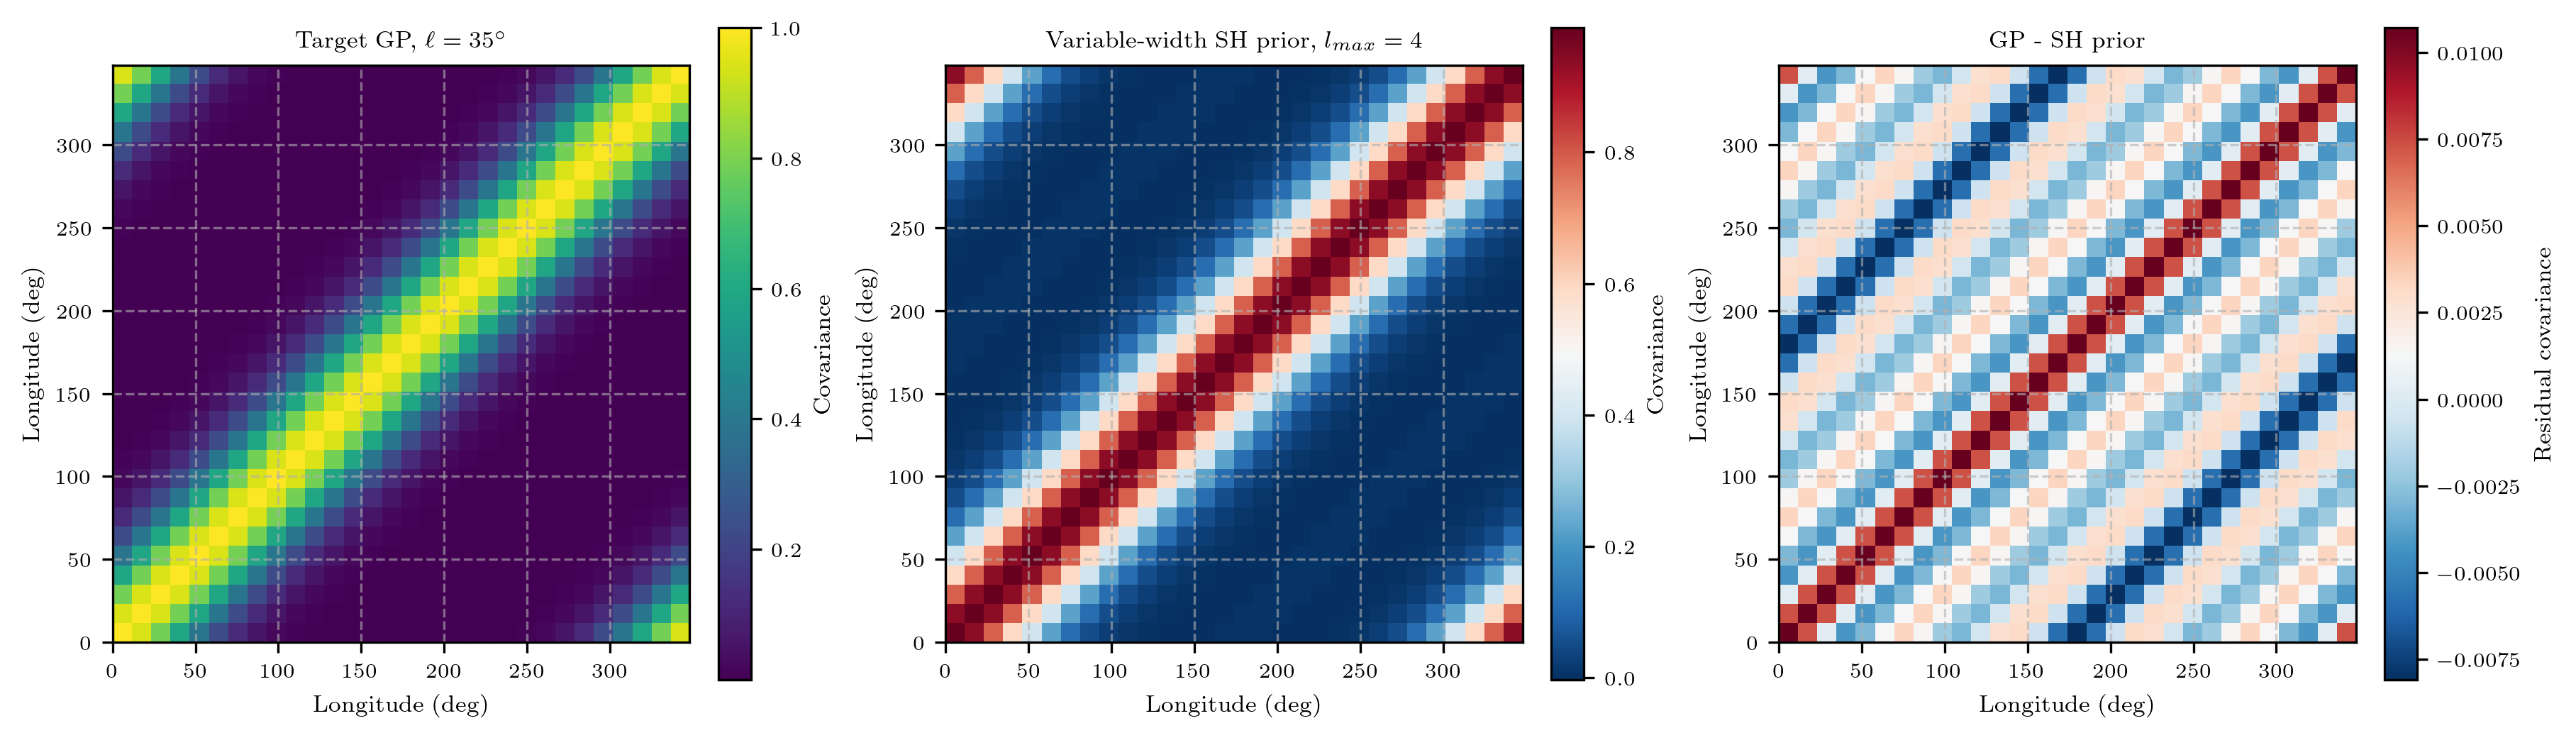

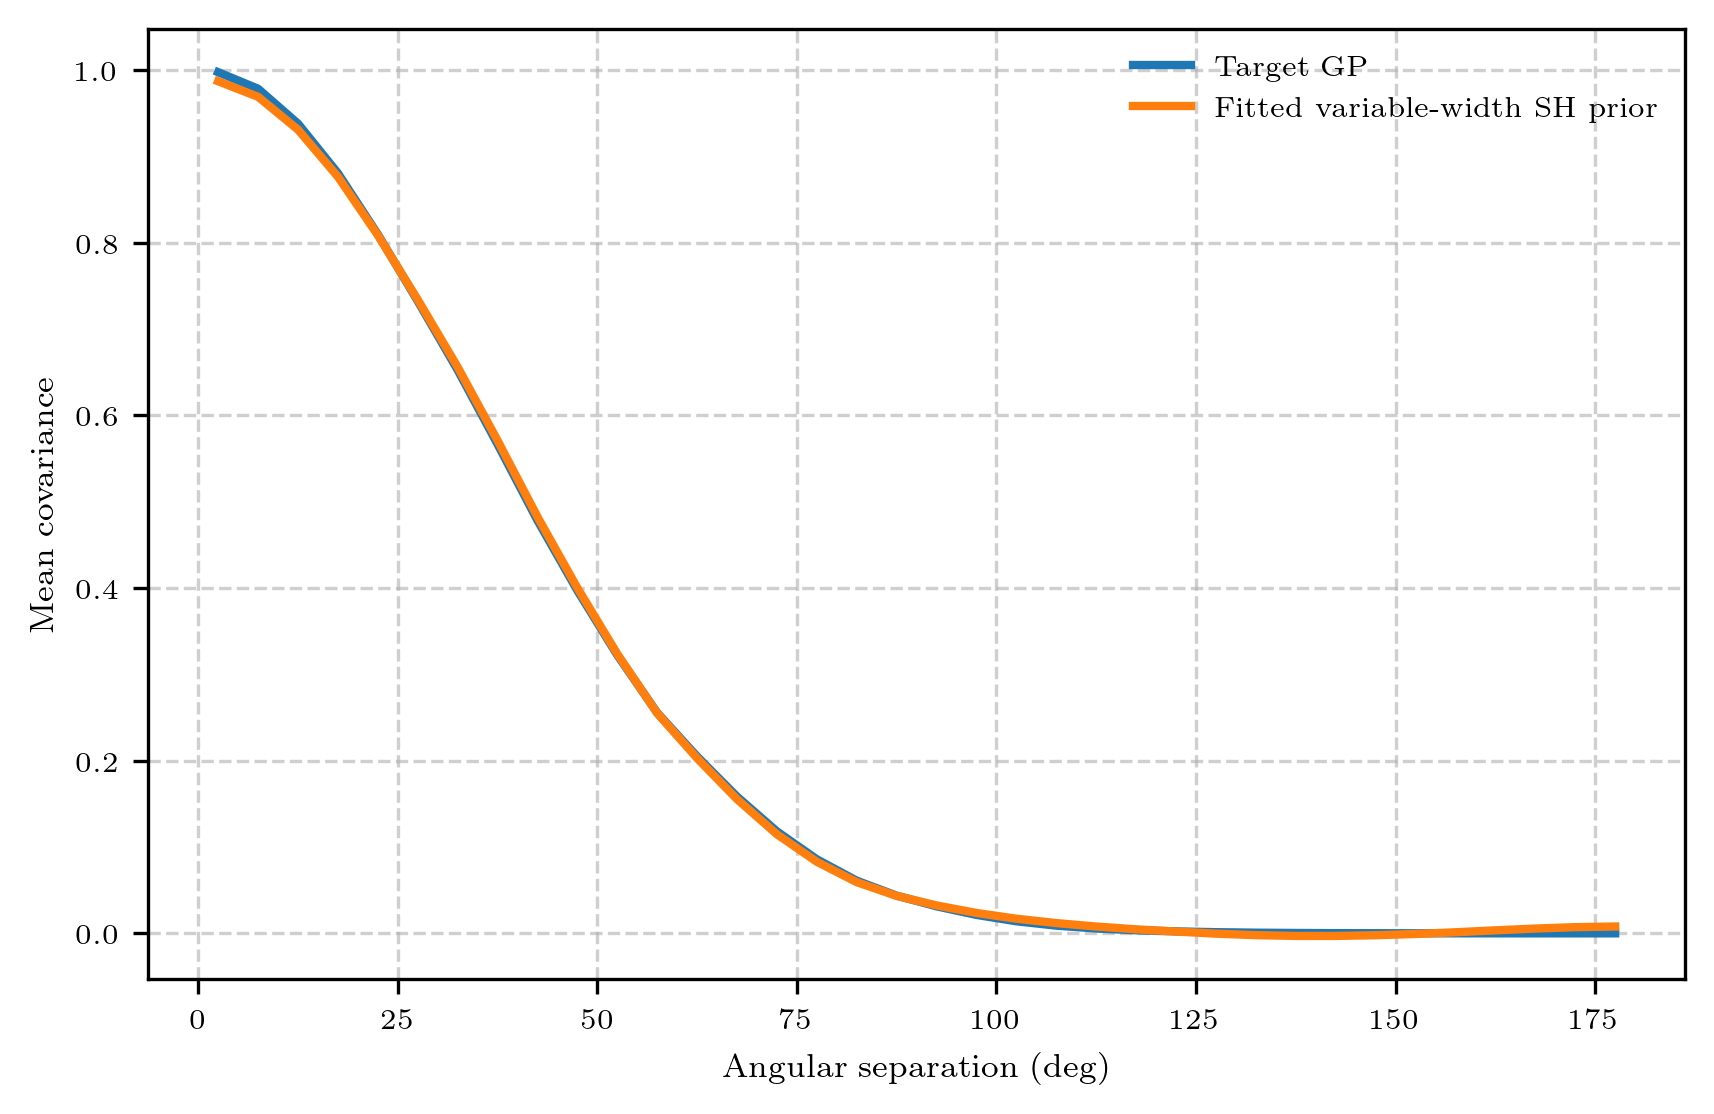

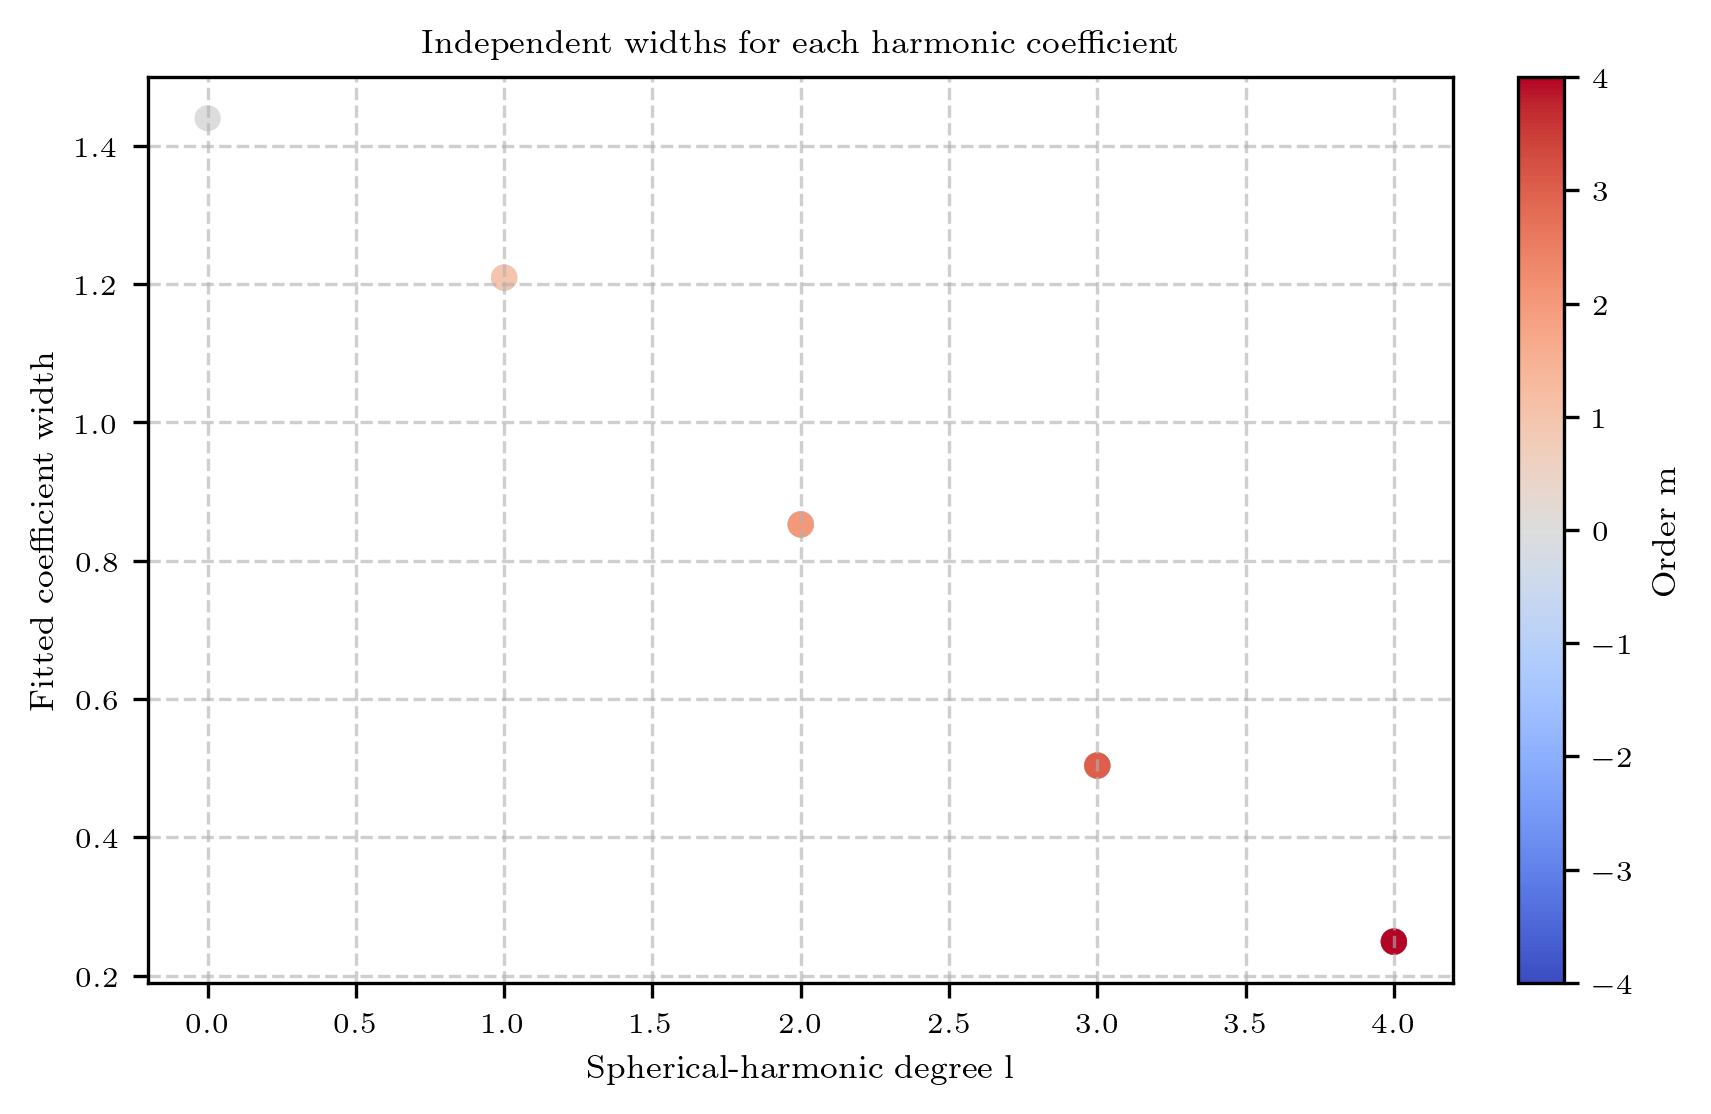

In [25]:
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
try:
    from scipy.special import sph_harm_y
except ImportError:
    from scipy.special import sph_harm as _sph_harm

    def complex_sph_harm(l, m, lon, colat):
        return _sph_harm(m, l, lon, colat)
else:

    def complex_sph_harm(l, m, lon, colat):
        return sph_harm_y(l, m, colat, lon)

# Target GP and spherical-harmonic prior settings.
gp_ell_deg = 35.0
lmax_prior = 4
prior_grid_res = 30

# Use cell-centered latitude samples to avoid duplicate points exactly at the poles.
longitude_deg = np.linspace(0.0, 360.0, prior_grid_res, endpoint=False)
latitude_deg = np.linspace(-90.0, 90.0, prior_grid_res + 1)
latitude_deg = 0.5 * (latitude_deg[:-1] + latitude_deg[1:])
lon_grid_deg, lat_grid_deg = np.meshgrid(longitude_deg, latitude_deg, indexing="ij")
lon = np.deg2rad(lon_grid_deg.ravel())
lat = np.deg2rad(lat_grid_deg.ravel())
colat = np.pi / 2.0 - lat

xyz = np.column_stack([
    np.cos(lat) * np.cos(lon),
    np.cos(lat) * np.sin(lon),
    np.sin(lat),
])
cos_gamma = np.clip(xyz @ xyz.T, -1.0, 1.0)
gamma = np.arccos(cos_gamma)
gp_ell = np.deg2rad(gp_ell_deg)
gp_cov = np.exp(-0.5 * (gamma / gp_ell) ** 2)


def real_sph_harm(l, m, lon, colat):
    """Real orthonormal spherical harmonic using scipy's complex convention."""
    if m < 0:
        return np.sqrt(2.0) * (-1) ** m * complex_sph_harm(l, -m, lon, colat).imag
    if m == 0:
        return complex_sph_harm(l, 0, lon, colat).real
    return np.sqrt(2.0) * (-1) ** m * complex_sph_harm(l, m, lon, colat).real


basis_columns = []
basis_labels = []
for degree in range(lmax_prior + 1):
    for order in range(-degree, degree + 1):
        basis_columns.append(real_sph_harm(degree, order, lon, colat))
        basis_labels.append((degree, order))
Y = np.column_stack(basis_columns)
basis_degrees = np.array([degree for degree, order in basis_labels])
basis_orders = np.array([order for degree, order in basis_labels])

# Fit one nonnegative coefficient variance per harmonic:
#     a_lm ~ Normal(0, width_lm**2)
#     K_SH = sum_lm width_lm**2 Y_lm Y_lm^T
# The weighted normal equations avoid building a huge dense design matrix.
area_weights = np.cos(lat)
weighted_basis_gram = Y.T @ (area_weights[:, None] * Y)
normal_matrix = weighted_basis_gram**2
weighted_gp_cov = area_weights[:, None] * gp_cov * area_weights[None, :]
rhs = np.sum(Y * (weighted_gp_cov @ Y), axis=0)

initial_variance = np.maximum(rhs / np.maximum(np.diag(normal_matrix), 1e-30), 0.0)


def variance_objective(variance):
    return 0.5 * variance @ normal_matrix @ variance - rhs @ variance


def variance_gradient(variance):
    return normal_matrix @ variance - rhs


fit_result = minimize(
    variance_objective,
    initial_variance,
    jac=variance_gradient,
    bounds=[(0.0, None)] * Y.shape[1],
    method="L-BFGS-B",
    options={"maxiter": 1000},
)
coefficient_variance = np.maximum(fit_result.x, 0.0)
coefficient_widths = np.sqrt(coefficient_variance)
sh_prior_cov = (Y * coefficient_variance) @ Y.T
residual_cov = gp_cov - sh_prior_cov
weight_outer = area_weights[:, None] * area_weights[None, :]
target_weighted_squared_norm = np.sum(weight_outer * gp_cov**2)
flexible_squared_difference = np.sum(weight_outer * residual_cov**2)
flexible_mean_squared_difference = flexible_squared_difference / np.sum(weight_outer)
flexible_relative_squared_difference = flexible_squared_difference / target_weighted_squared_norm
flexible_relative_rms = np.sqrt(flexible_relative_squared_difference)

print(f"Target GP ell = {gp_ell_deg:.1f} deg")
print(f"Spherical-harmonic lmax = {lmax_prior}")
print(f"Fitted {coefficient_widths.size} independent harmonic widths")
print(f"Optimizer success = {fit_result.success}")
print(f"Per-coefficient weighted squared difference = {flexible_squared_difference:.3e}")
print(f"Per-coefficient weighted mean squared difference = {flexible_mean_squared_difference:.3e}")
print(f"Per-coefficient relative squared difference = {flexible_relative_squared_difference:.3e}")
print(f"Per-coefficient relative RMS residual = {flexible_relative_rms:.3e}")

# Visualize the longitude-longitude covariance matrix exactly at latitude 0 deg.
lon_slice = np.deg2rad(longitude_deg)
lat_slice = np.zeros_like(lon_slice)
colat_slice = np.pi / 2.0 - lat_slice
xyz_slice = np.column_stack([
    np.cos(lat_slice) * np.cos(lon_slice),
    np.cos(lat_slice) * np.sin(lon_slice),
    np.sin(lat_slice),
])
gamma_slice = np.arccos(np.clip(xyz_slice @ xyz_slice.T, -1.0, 1.0))
gp_lon_cov = np.exp(-0.5 * (gamma_slice / gp_ell) ** 2)
Y_lon_slice = np.column_stack([
    real_sph_harm(degree, order, lon_slice, colat_slice)
    for degree, order in basis_labels
])
sh_lon_cov = (Y_lon_slice * coefficient_variance) @ Y_lon_slice.T
residual_lon_cov = gp_lon_cov - sh_lon_cov

gp_asymmetry = np.max(np.abs(gp_lon_cov - gp_lon_cov.T))
sh_asymmetry = np.max(np.abs(sh_lon_cov - sh_lon_cov.T))
print("Longitude covariance slice latitude = 0.0 deg")
print(f"Max GP covariance asymmetry = {gp_asymmetry:.3e}")
print(f"Max SH covariance asymmetry = {sh_asymmetry:.3e}")

extent = [longitude_deg.min(), longitude_deg.max(), longitude_deg.min(), longitude_deg.max()]


def plot_covariance_matrix(ax, matrix, title, *, positive=False, colorbar_label="Covariance"):
    vmin = float(np.nanmin(matrix))
    vmax = float(np.nanmax(matrix))
    if (not np.isfinite(vmin)) or (not np.isfinite(vmax)):
        vmin, vmax = 0.0, 1.0
    elif vmin == vmax:
        pad = 1.0 if vmin == 0.0 else 0.05 * abs(vmin)
        vmin -= pad
        vmax += pad
    cmap = "viridis" if positive else "RdBu_r"

    image = ax.imshow(
        matrix,
        aspect="equal",
        origin="lower",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
    )
    ax.set_title(title)
    ax.set_xlabel("Longitude (deg)")
    ax.set_ylabel("Longitude (deg)")
    ax.figure.colorbar(image, ax=ax, label=colorbar_label)
    return image


fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), constrained_layout=True)
plot_covariance_matrix(axes[0], gp_lon_cov, rf"Target GP, $\ell={gp_ell_deg:.0f}^\circ$", positive=True)
plot_covariance_matrix(axes[1], sh_lon_cov, rf"Variable-width SH prior, $l_{{max}}={lmax_prior}$")
plot_covariance_matrix(axes[2], residual_lon_cov, "GP - SH prior", colorbar_label="Residual covariance")

# Compare isotropic covariance profiles by angular separation.
gamma_deg = np.rad2deg(gamma.ravel())
gp_values = gp_cov.ravel()
sh_values = sh_prior_cov.ravel()
bins = np.linspace(0.0, 180.0, 37)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
gp_profile = np.full_like(bin_centers, np.nan, dtype=float)
sh_profile = np.full_like(bin_centers, np.nan, dtype=float)
for i_bin, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
    in_bin = (gamma_deg >= lo) & (gamma_deg < hi)
    if np.any(in_bin):
        gp_profile[i_bin] = np.average(gp_values[in_bin])
        sh_profile[i_bin] = np.average(sh_values[in_bin])

fig, ax = plt.subplots(figsize=(5.6, 3.6), constrained_layout=True)
ax.plot(bin_centers, gp_profile, label="Target GP", linewidth=2)
ax.plot(bin_centers, sh_profile, label="Fitted variable-width SH prior", linewidth=2)
ax.set_xlabel("Angular separation (deg)")
ax.set_ylabel("Mean covariance")
ax.legend(frameon=False)

fig, ax = plt.subplots(figsize=(5.6, 3.6), constrained_layout=True)
points = ax.scatter(basis_degrees, coefficient_widths, c=basis_orders, cmap="coolwarm", s=28)
ax.set_xlabel("Spherical-harmonic degree l")
ax.set_ylabel("Fitted coefficient width")
ax.set_title("Independent widths for each harmonic coefficient")
fig.colorbar(points, ax=ax, label="Order m")


Degree-width optimizer success = True
Degree-width weighted squared difference = 2.613e+00
Degree-width weighted mean squared difference = 7.953e-06
Degree-width relative squared difference = 9.069e-05
Degree-width relative RMS residual = 9.523e-03
Max degree-width covariance asymmetry = 0.000e+00


Text(0.5, 1.0, 'Degree-tied harmonic prior widths')

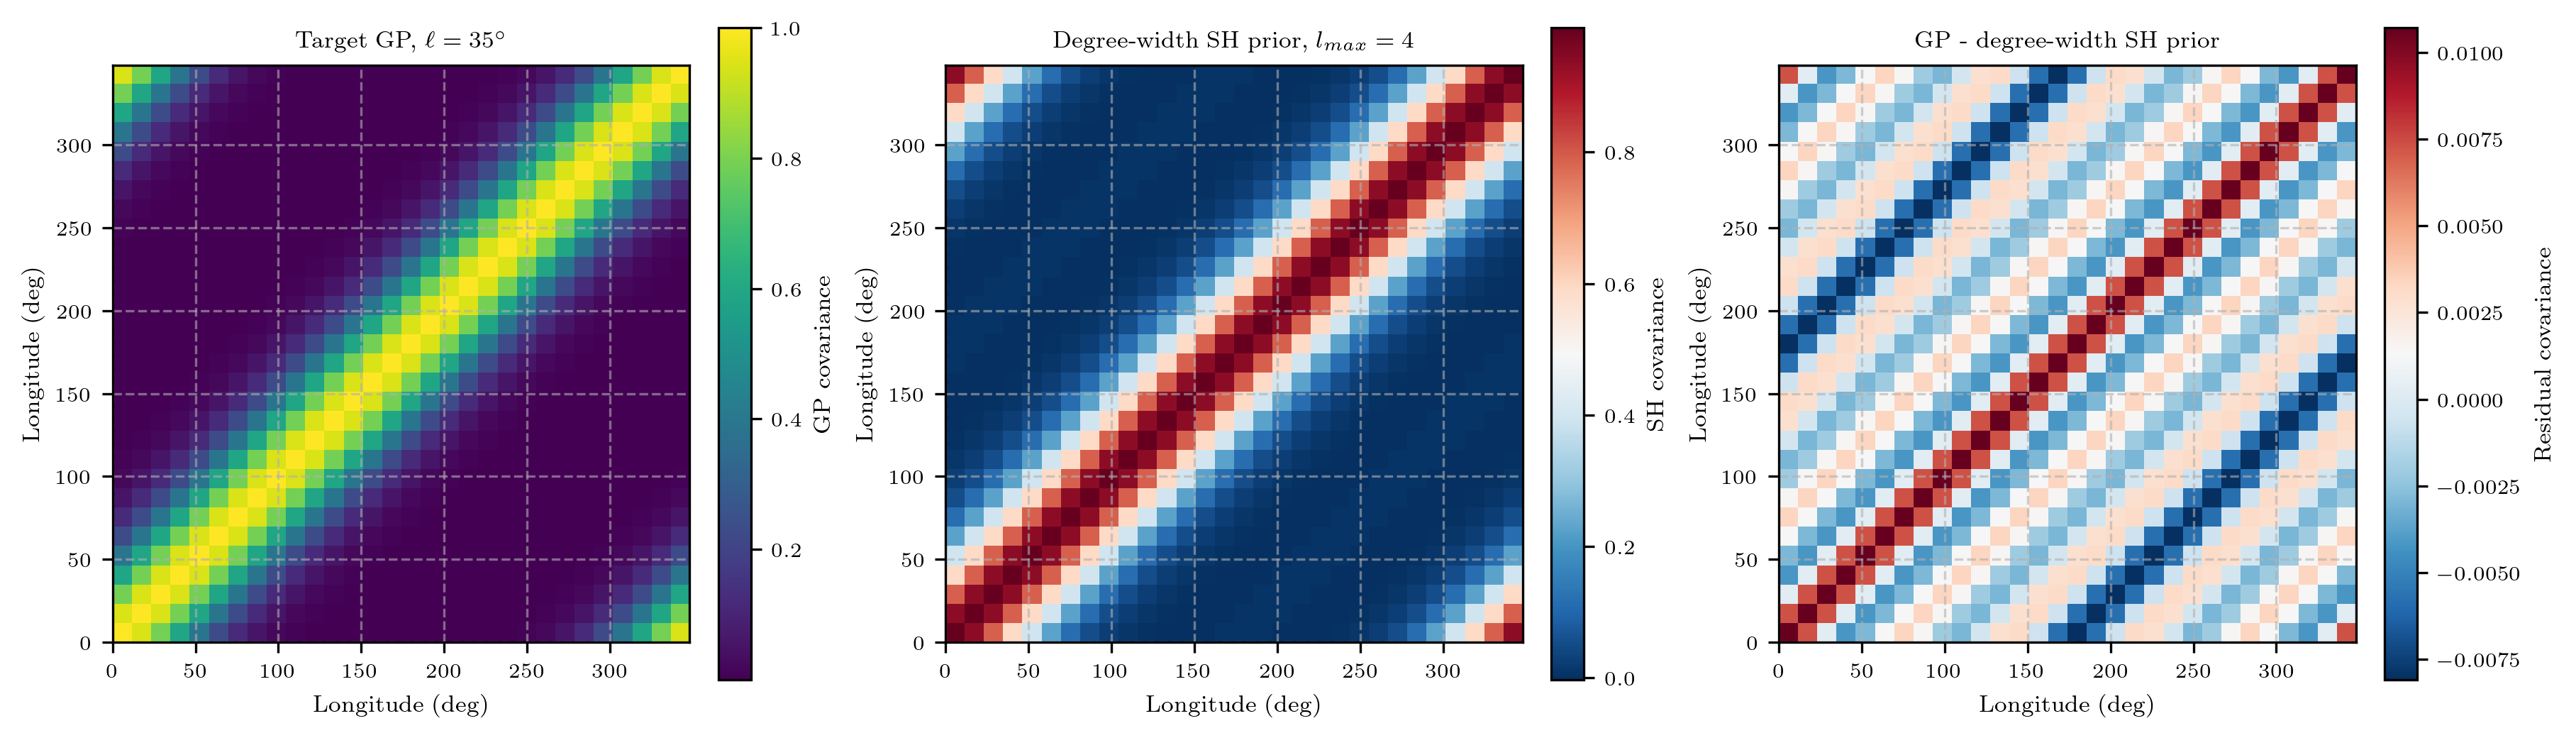

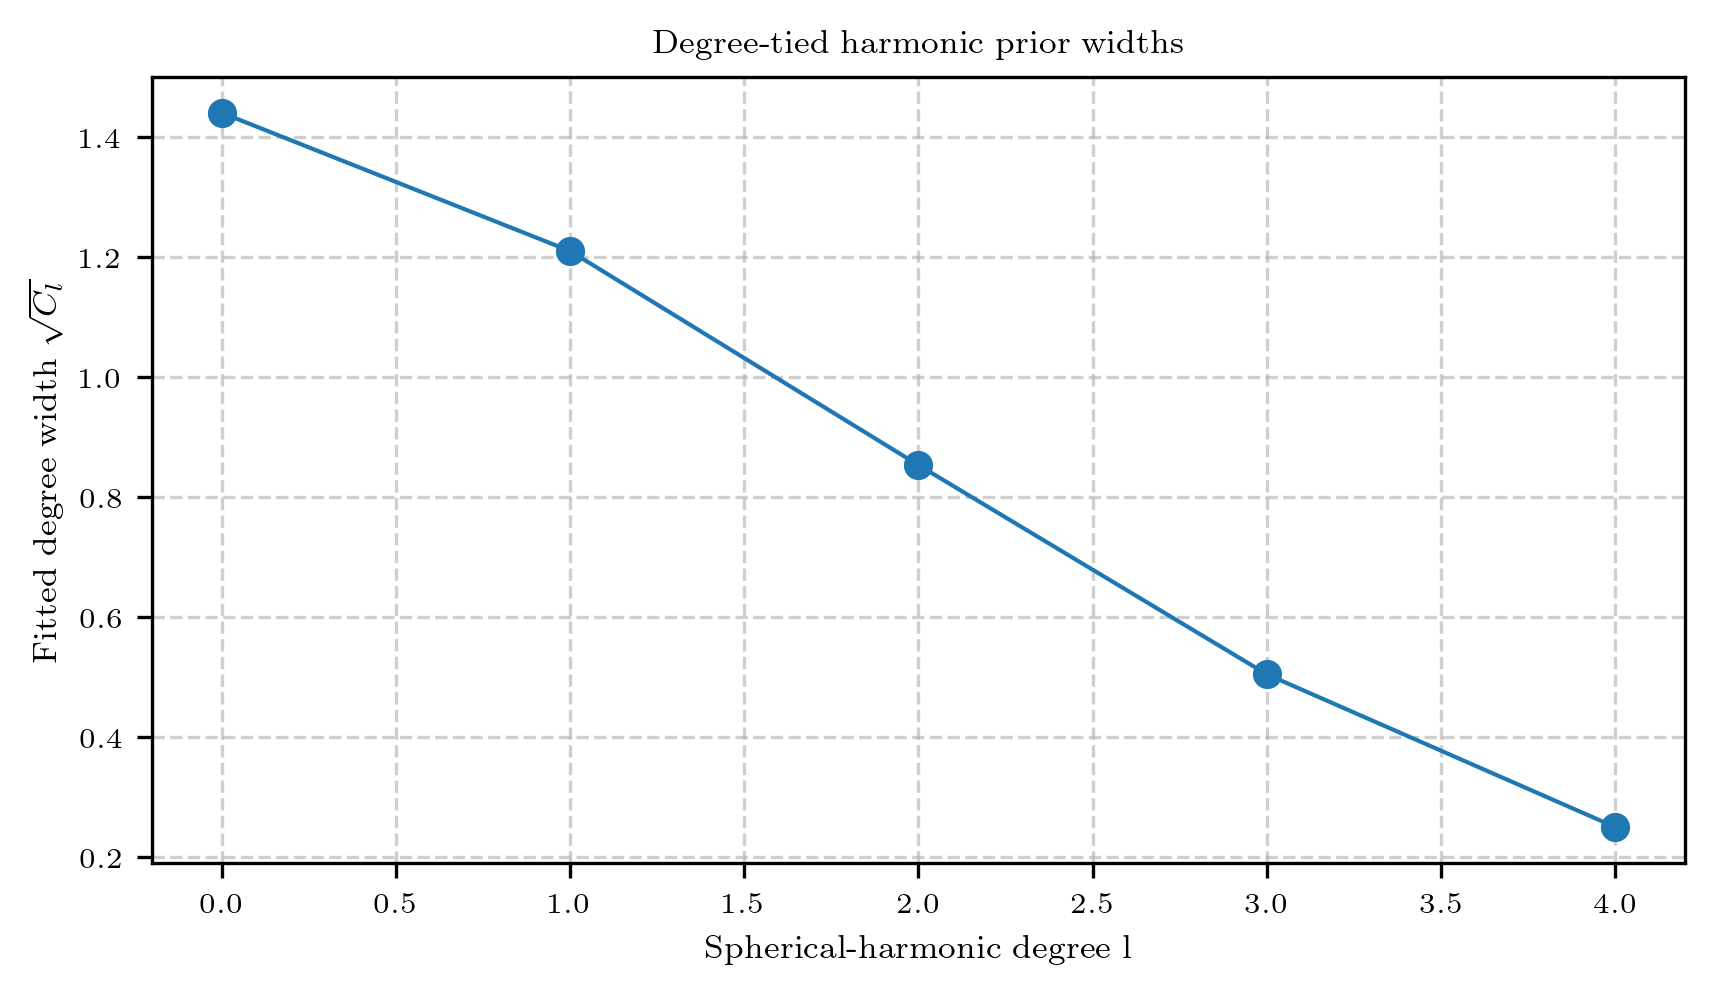

In [26]:
# Degree-width harmonic prior: one shared variance C_l for all orders m at fixed degree l.
degrees = np.arange(lmax_prior + 1)
degree_covariances = []
for degree in degrees:
    Y_l = Y[:, basis_degrees == degree]
    degree_covariances.append(Y_l @ Y_l.T)

weighted_degree_covariances = [
    area_weights[:, None] * degree_cov * area_weights[None, :]
    for degree_cov in degree_covariances
]
degree_normal_matrix = np.array([
    [np.sum(weighted_degree_covariances[i] * degree_covariances[j]) for j in range(len(degrees))]
    for i in range(len(degrees))
])
degree_rhs = np.array([
    np.sum(weighted_gp_cov * degree_cov) for degree_cov in degree_covariances
])
initial_degree_variance = np.maximum(
    degree_rhs / np.maximum(np.diag(degree_normal_matrix), 1e-30),
    0.0,
)


def degree_variance_objective(degree_variance):
    return 0.5 * degree_variance @ degree_normal_matrix @ degree_variance - degree_rhs @ degree_variance


def degree_variance_gradient(degree_variance):
    return degree_normal_matrix @ degree_variance - degree_rhs


degree_fit_result = minimize(
    degree_variance_objective,
    initial_degree_variance,
    jac=degree_variance_gradient,
    bounds=[(0.0, None)] * len(degrees),
    method="L-BFGS-B",
    options={"maxiter": 1000},
)
degree_variance = np.maximum(degree_fit_result.x, 0.0)
degree_widths = np.sqrt(degree_variance)

degree_width_prior_cov = sum(
    variance * degree_cov
    for variance, degree_cov in zip(degree_variance, degree_covariances)
)
degree_width_residual_cov = gp_cov - degree_width_prior_cov
degree_width_squared_difference = np.sum(weight_outer * degree_width_residual_cov**2)
degree_width_mean_squared_difference = degree_width_squared_difference / np.sum(weight_outer)
degree_width_relative_squared_difference = degree_width_squared_difference / target_weighted_squared_norm
degree_width_relative_rms = np.sqrt(degree_width_relative_squared_difference)

Y_lon_slice = np.column_stack([
    real_sph_harm(degree, order, lon_slice, colat_slice)
    for degree, order in basis_labels
])
degree_width_lon_cov = np.zeros_like(gp_lon_cov)
for degree, variance in zip(degrees, degree_variance):
    Y_l_slice = Y_lon_slice[:, basis_degrees == degree]
    degree_width_lon_cov += variance * (Y_l_slice @ Y_l_slice.T)
degree_width_residual_lon_cov = gp_lon_cov - degree_width_lon_cov

print(f"Degree-width optimizer success = {degree_fit_result.success}")
print(f"Degree-width weighted squared difference = {degree_width_squared_difference:.3e}")
print(f"Degree-width weighted mean squared difference = {degree_width_mean_squared_difference:.3e}")
print(f"Degree-width relative squared difference = {degree_width_relative_squared_difference:.3e}")
print(f"Degree-width relative RMS residual = {degree_width_relative_rms:.3e}")
print(f"Max degree-width covariance asymmetry = {np.max(np.abs(degree_width_lon_cov - degree_width_lon_cov.T)):.3e}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), constrained_layout=True)
plot_covariance_matrix(axes[0], gp_lon_cov, rf"Target GP, $\ell={gp_ell_deg:.0f}^\circ$", positive=True, colorbar_label="GP covariance")
plot_covariance_matrix(axes[1], degree_width_lon_cov, rf"Degree-width SH prior, $l_{{max}}={lmax_prior}$", colorbar_label="SH covariance")
plot_covariance_matrix(axes[2], degree_width_residual_lon_cov, "GP - degree-width SH prior", colorbar_label="Residual covariance")

fig, ax = plt.subplots(figsize=(5.6, 3.2), constrained_layout=True)
ax.plot(degrees, degree_widths, marker="o")
ax.set_xlabel("Spherical-harmonic degree l")
ax.set_ylabel(r"Fitted degree width $\sqrt{C_l}$")
ax.set_title("Degree-tied harmonic prior widths")


Single shared coefficient width = 7.052e-01
Single-width weighted squared difference = 1.595e+04
Single-width weighted mean squared difference = 4.855e-02
Single-width relative squared difference = 5.536e-01
Single-width relative RMS residual = 7.440e-01
Max single-width covariance asymmetry = 0.000e+00


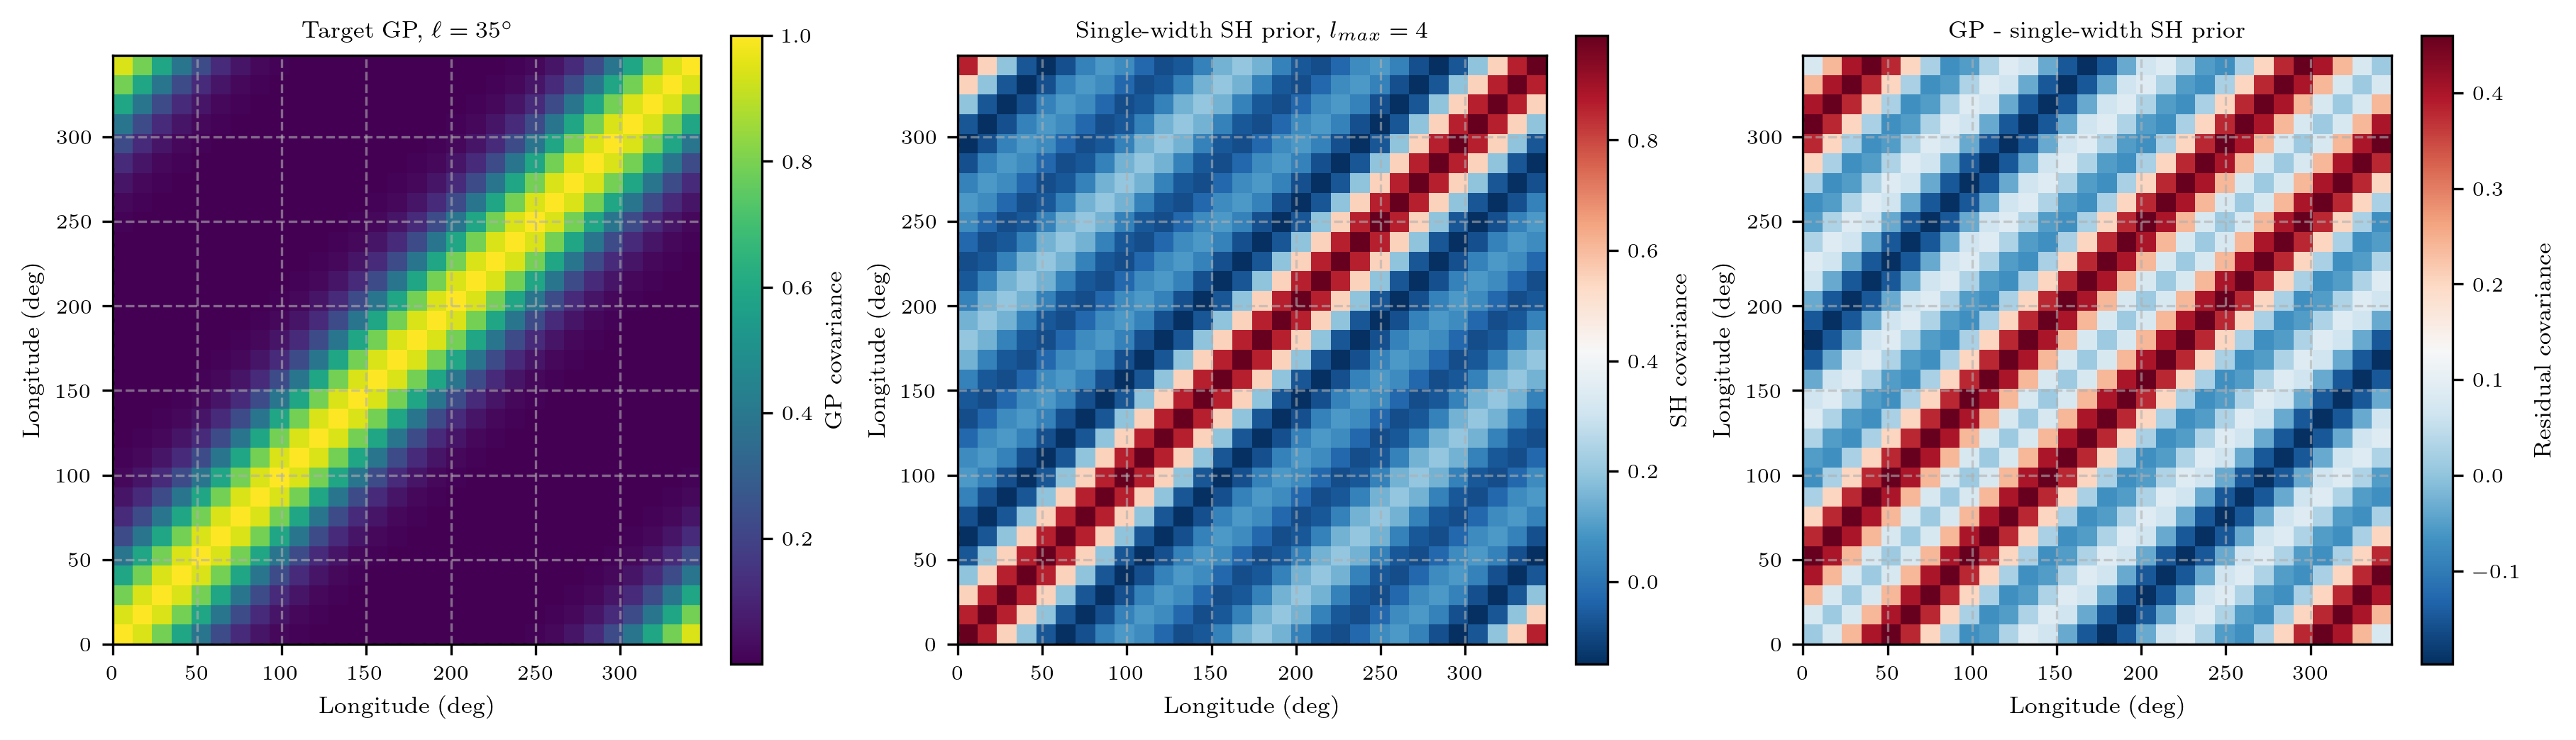

In [27]:
# Single-width harmonic prior: one shared variance for every coefficient through lmax_prior.
unit_width_cov = Y @ Y.T
weighted_unit_width_cov = area_weights[:, None] * unit_width_cov * area_weights[None, :]
single_variance = np.sum(weighted_gp_cov * unit_width_cov) / np.sum(weighted_unit_width_cov * unit_width_cov)
single_variance = max(single_variance, 0.0)
single_width = np.sqrt(single_variance)

single_width_prior_cov = single_variance * unit_width_cov
single_width_residual_cov = gp_cov - single_width_prior_cov
single_width_squared_difference = np.sum(weight_outer * single_width_residual_cov**2)
single_width_mean_squared_difference = single_width_squared_difference / np.sum(weight_outer)
single_width_relative_squared_difference = single_width_squared_difference / target_weighted_squared_norm
single_width_relative_rms = np.sqrt(single_width_relative_squared_difference)

Y_lon_slice = np.column_stack([
    real_sph_harm(degree, order, lon_slice, colat_slice)
    for degree, order in basis_labels
])
single_width_lon_cov = single_variance * (Y_lon_slice @ Y_lon_slice.T)
single_width_residual_lon_cov = gp_lon_cov - single_width_lon_cov

print(f"Single shared coefficient width = {single_width:.3e}")
print(f"Single-width weighted squared difference = {single_width_squared_difference:.3e}")
print(f"Single-width weighted mean squared difference = {single_width_mean_squared_difference:.3e}")
print(f"Single-width relative squared difference = {single_width_relative_squared_difference:.3e}")
print(f"Single-width relative RMS residual = {single_width_relative_rms:.3e}")
print(f"Max single-width covariance asymmetry = {np.max(np.abs(single_width_lon_cov - single_width_lon_cov.T)):.3e}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), constrained_layout=True)
plot_covariance_matrix(axes[0], gp_lon_cov, rf"Target GP, $\ell={gp_ell_deg:.0f}^\circ$", positive=True, colorbar_label="GP covariance")
plot_covariance_matrix(axes[1], single_width_lon_cov, rf"Single-width SH prior, $l_{{max}}={lmax_prior}$", colorbar_label="SH covariance")
plot_covariance_matrix(axes[2], single_width_residual_lon_cov, "GP - single-width SH prior", colorbar_label="Residual covariance")


Fixed isotropic coefficient width = 2.000e-02
Fixed isotropic covariance min = -1.206e-04
Fixed isotropic covariance max = 7.958e-04
Max fixed isotropic covariance asymmetry = 0.000e+00


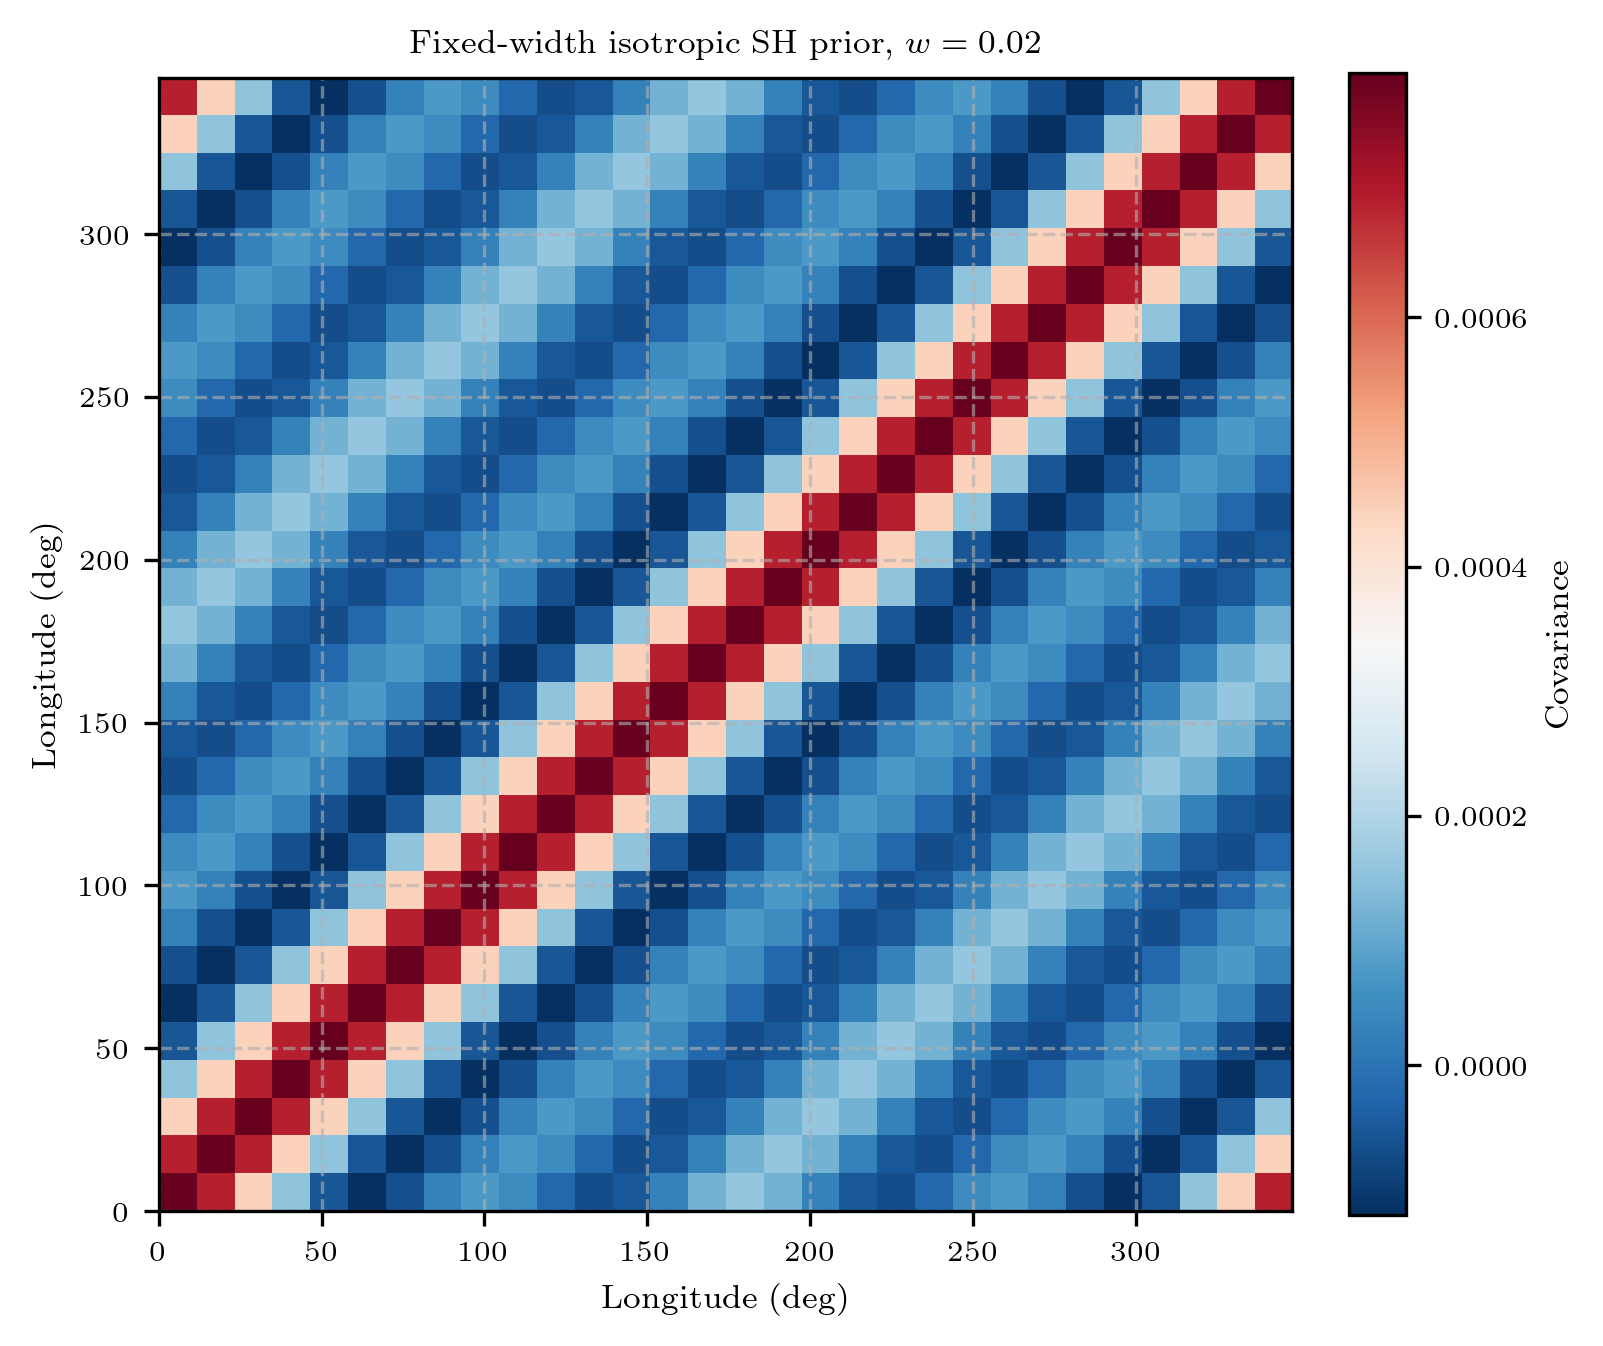

In [28]:
# Fixed single-width isotropic prior at latitude 0 deg.
fixed_isotropic_width = 0.02
fixed_isotropic_variance = fixed_isotropic_width**2

Y_lon_slice = np.column_stack([
    real_sph_harm(degree, order, lon_slice, colat_slice)
    for degree, order in basis_labels
])
fixed_isotropic_lon_cov = fixed_isotropic_variance * (Y_lon_slice @ Y_lon_slice.T)

print(f"Fixed isotropic coefficient width = {fixed_isotropic_width:.3e}")
print(f"Fixed isotropic covariance min = {fixed_isotropic_lon_cov.min():.3e}")
print(f"Fixed isotropic covariance max = {fixed_isotropic_lon_cov.max():.3e}")
print(f"Max fixed isotropic covariance asymmetry = {np.max(np.abs(fixed_isotropic_lon_cov - fixed_isotropic_lon_cov.T)):.3e}")

fig, ax = plt.subplots(figsize=(5.2, 4.4), constrained_layout=True)
plot_covariance_matrix(ax, fixed_isotropic_lon_cov, rf"Fixed-width isotropic SH prior, $w={fixed_isotropic_width:.2f}$")


Exponential prior width0 = 1.000e-01
Exponential prior decay scale in l = 3.00
Exponential prior covariance min = 1.242e-04
Exponential prior covariance max = 4.322e-03
Max exponential-prior covariance asymmetry = 0.000e+00


Text(0.5, 1.0, '$w_l=0.10\\,e^{-l/3.0}$')

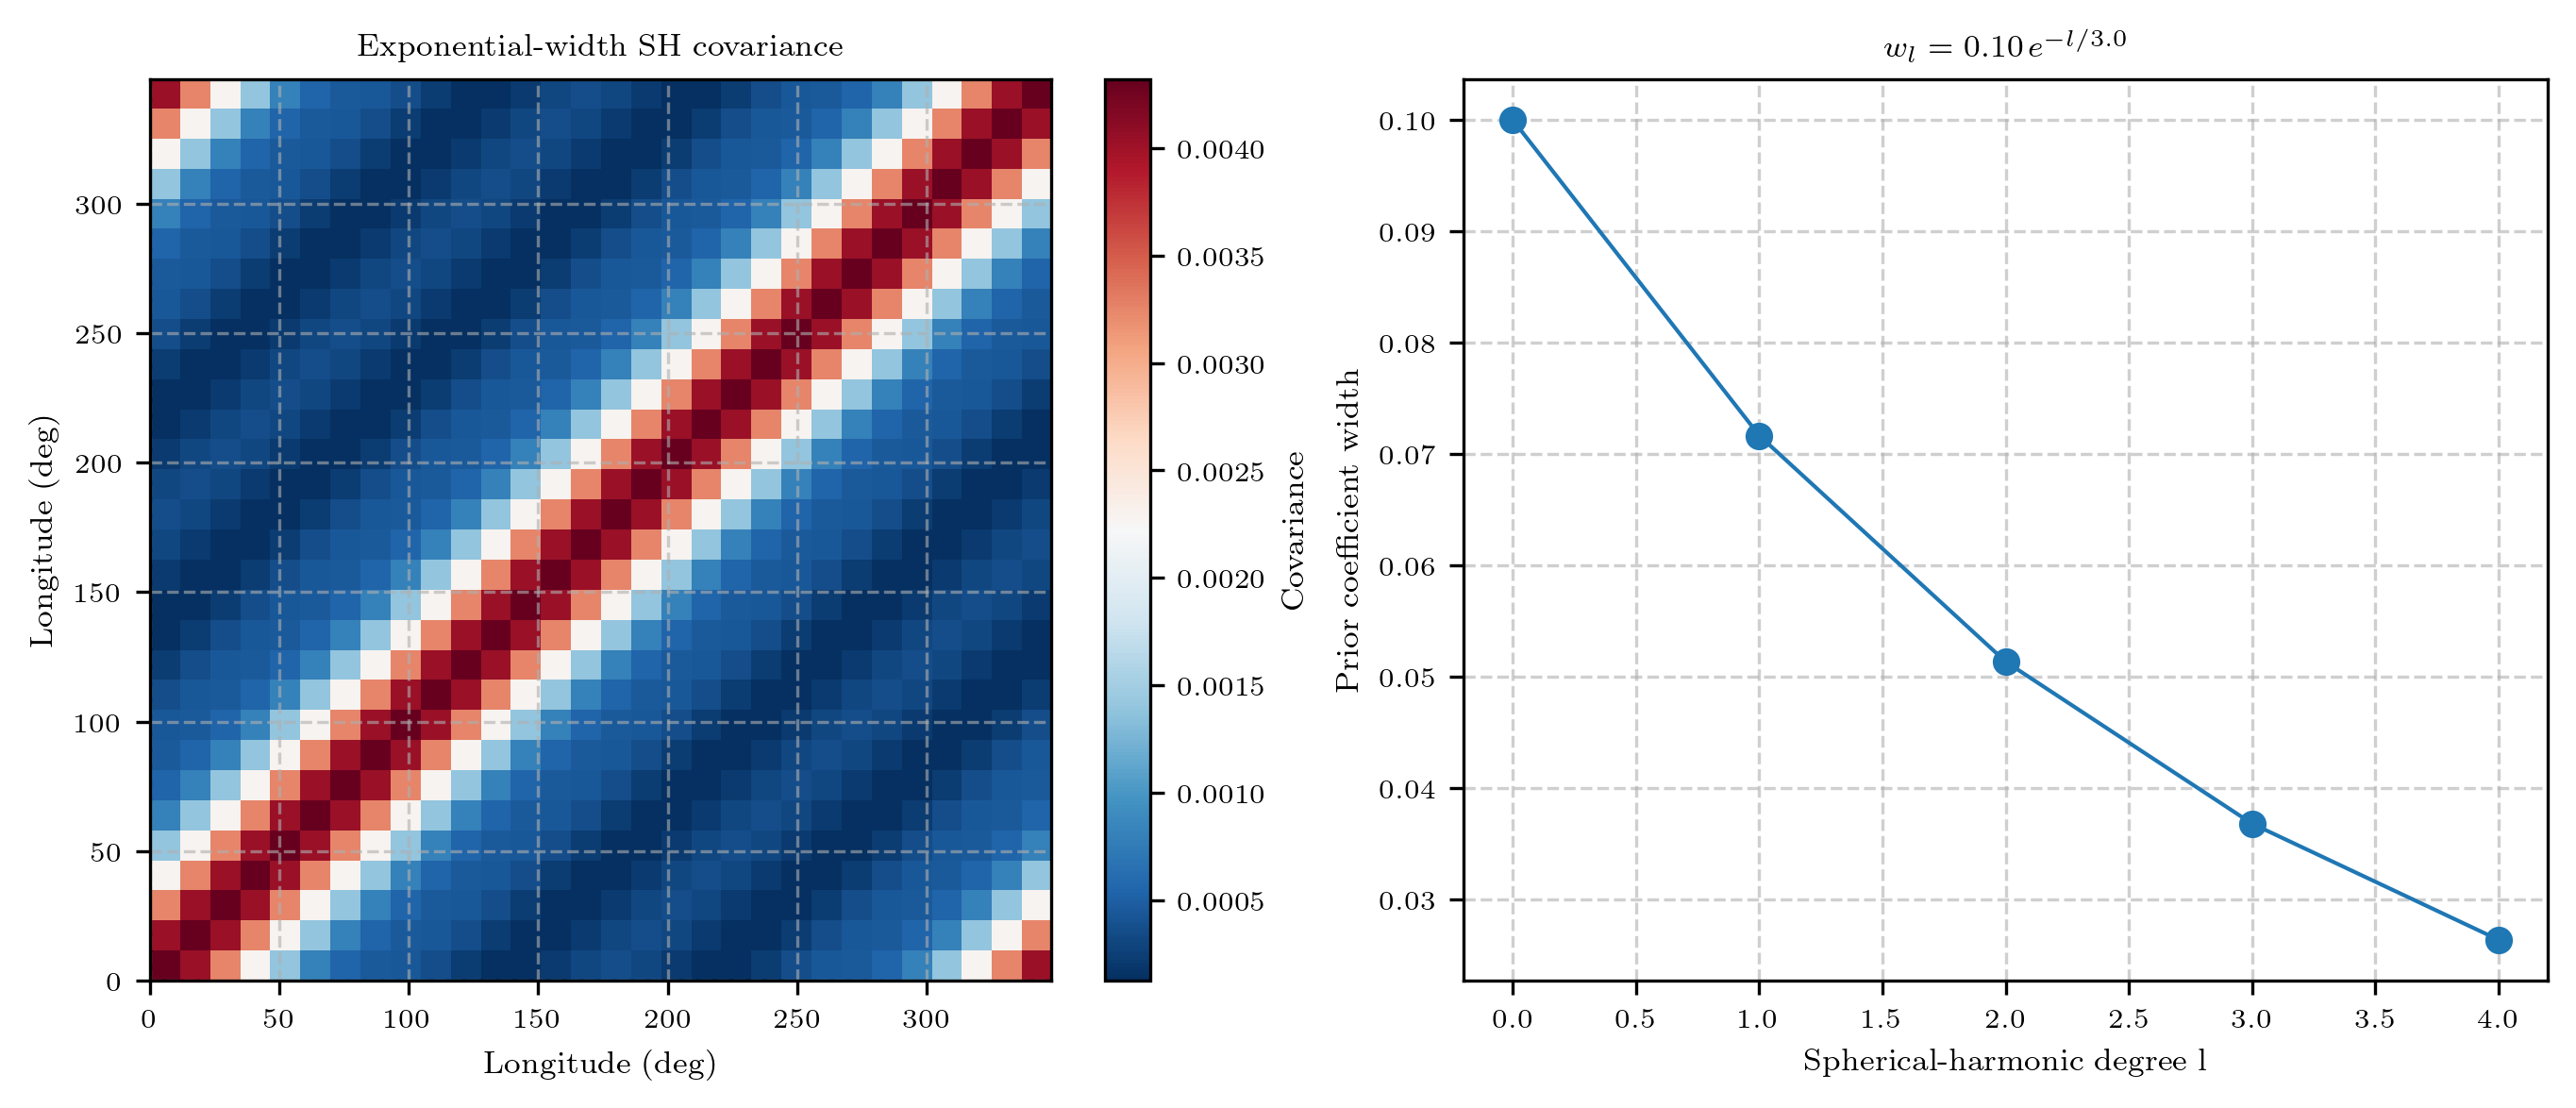

In [29]:
# Fixed exponentially decaying isotropic prior at latitude 0 deg.
# These constants are arbitrary and only illustrate how suppressing high-l modes smooths the covariance.
exp_width0 = 0.10
exp_decay_scale = 3.0
exp_degree_widths = exp_width0 * np.exp(-degrees / exp_decay_scale)
exp_degree_variance = exp_degree_widths**2

Y_lon_slice = np.column_stack([
    real_sph_harm(degree, order, lon_slice, colat_slice)
    for degree, order in basis_labels
])
exp_decay_lon_cov = np.zeros_like(gp_lon_cov)
for degree, variance in zip(degrees, exp_degree_variance):
    Y_l_slice = Y_lon_slice[:, basis_degrees == degree]
    exp_decay_lon_cov += variance * (Y_l_slice @ Y_l_slice.T)

print(f"Exponential prior width0 = {exp_width0:.3e}")
print(f"Exponential prior decay scale in l = {exp_decay_scale:.2f}")
print(f"Exponential prior covariance min = {exp_decay_lon_cov.min():.3e}")
print(f"Exponential prior covariance max = {exp_decay_lon_cov.max():.3e}")
print(f"Max exponential-prior covariance asymmetry = {np.max(np.abs(exp_decay_lon_cov - exp_decay_lon_cov.T)):.3e}")

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), constrained_layout=True)
plot_covariance_matrix(axes[0], exp_decay_lon_cov, "Exponential-width SH covariance")

axes[1].plot(degrees, exp_degree_widths, marker="o")
axes[1].set_xlabel("Spherical-harmonic degree l")
axes[1].set_ylabel("Prior coefficient width")
axes[1].set_title(rf"$w_l={exp_width0:.2f}\,e^{{-l/{exp_decay_scale:.1f}}}$")


## 4. Clustering and Regional Identification
To make sense of the map, we group surface areas that show similar spectral behavior using a clustering algorithm. This helps us identify distinct regions or features on the object's surface. Averaging spatial spectra within these regions gives us regional spectra, which are accessible through the Maps object.

In [ ]:
maps.find_clusters(n_neighbors=100, n_corners=3, plot=True)

## 5. Results
Finally, we visualize the identified regions on the map and plot the regional spectra.

In [ ]:
from spectralmap.plotting import plot_pc_projection, plot_labels, plot_spectra
plot_pc_projection(maps)

In [ ]:
plot_labels(maps)

In [ ]:
plot_spectra(maps)

In [ ]:
maps_no_null = make_maps(map_res=30, u=u_wl, verbose=True)
maps_no_null.null_uncertainty = False
maps_no_null.marginalize(data, ydeg=np.arange(2, 8), inc=[70, 80, 90], prot=None)
maps_no_null.find_clusters(n_neighbors=100, n_corners=3, plot=True)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerPatch
from scipy.ndimage import gaussian_filter1d
from spectralmap.plotting import COLOR_LIST

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

regional_spectra = maps.regional_spectra
regional_spectra_std = maps.regional_spectra_std
regional_spectra_std_no_null = maps_no_null.regional_spectra_std
background_flux = regional_spectra[0]
wl = maps.data.wl
gaussian_sigma = 1
N = regional_spectra.shape[0]
color_list = COLOR_LIST[:N]
cluster_names = ["Background"] + [f"Region {i+1}" for i in range(N - 1)]

for i in range(1, N):
    mean_flux = regional_spectra[i]
    error_flux = regional_spectra_std[i]
    error_flux_no_null = regional_spectra_std_no_null[i]
    color = color_list[i]

    axes[0].plot(wl, mean_flux, label=cluster_names[i], color=color, linewidth=1.2, linestyle="--")
    axes[0].fill_between(wl, mean_flux - error_flux, mean_flux + error_flux, alpha=0.12, color=color, linewidth=0)
    axes[0].fill_between(wl, mean_flux - error_flux_no_null, mean_flux + error_flux_no_null, alpha=0.35, color=color, linewidth=0)

    axes[1].plot(
        wl,
        gaussian_filter1d(mean_flux / background_flux, sigma=gaussian_sigma, mode="nearest"),
        color=color,
        linewidth=1.2,
        linestyle="--",
    )
    axes[1].fill_between(
        wl,
        gaussian_filter1d((mean_flux - error_flux) / background_flux, sigma=gaussian_sigma, mode="nearest"),
        gaussian_filter1d((mean_flux + error_flux) / background_flux, sigma=gaussian_sigma, mode="nearest"),
        alpha=0.12,
        color=color,
        linewidth=0,
    )
    axes[1].fill_between(
        wl,
        gaussian_filter1d((mean_flux - error_flux_no_null) / background_flux, sigma=gaussian_sigma, mode="nearest"),
        gaussian_filter1d((mean_flux + error_flux_no_null) / background_flux, sigma=gaussian_sigma, mode="nearest"),
        alpha=0.35,
        color=color,
        linewidth=0,
    )

axes[1].set_xlabel(r"Wavelength ($\mu$m)", fontsize=9)
axes[0].set_ylabel(r"Flux (W/m$^2$/$\mu$m)", fontsize=9)
axes[1].set_ylabel(r"F/$F_{\rm{mean}}$", fontsize=9)
axes[0].set_title("Recovered Regional Spectra")

class HandlerSmallRectangle(HandlerPatch):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        xpad = 0.12 * width
        ypad = 0.25 * height
        rect = Rectangle(
            (xdescent + xpad, ydescent + ypad),
            width - 2 * xpad,
            height - 2 * ypad,
            facecolor=orig_handle.get_facecolor(),
            edgecolor="none",
            alpha=orig_handle.get_alpha(),
            transform=trans,
        )
        return [rect]

legend_bbox = (0.68, 0.95, 0.3, 0.0)
legend_kwargs = dict(
    loc="upper left",
    mode="expand",
    borderaxespad=0.0,
    borderpad=0.25,
    labelspacing=0.35,
    handletextpad=0.6,
)

region_legend = axes[0].legend(
    bbox_to_anchor=legend_bbox,
    ncol=2,
    title="Region",
    columnspacing=1.0,
    **legend_kwargs,
)
axes[0].add_artist(region_legend)
axes[0].legend(
    handles=[
        Rectangle((0, 0), 1, 1, facecolor="black", alpha=0.12, label="With null uncertainty"),
        Rectangle((0, 0), 1, 1, facecolor="black", alpha=0.35, label="Without null uncertainty"),
    ],
    bbox_to_anchor=(legend_bbox[0], 0.75, legend_bbox[2], legend_bbox[3]),
    title="Uncertainty",
    handler_map={Rectangle: HandlerSmallRectangle()},
    **legend_kwargs,
)